In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
from tqdm import tqdm
import mne

# === Paths ===
EEG_DIR = "C:/Users/Kevin Tran/Documents/GitHub ED1/hms-harmful-brain-activity-classificationtrain_eegs/train_eegs"
PROCESSED_EEG_DIR = "C:/Users/Kevin Tran/Documents/Project Data/processed eegs2"
os.makedirs(PROCESSED_EEG_DIR, exist_ok=True)

# === Sampling Rate ===
FS = 200  # Hz

# === Preprocessing Functions ===
def apply_notch_filter(signal, fs=FS, freq=60.0, quality_factor=30):
    b, a = iirnotch(w0=freq, Q=quality_factor, fs=fs)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal, fs=FS, lowcut=0.5, highcut=40.0, order=5):
    nyquist = 0.5 * fs
    low, high = lowcut / nyquist, highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def normalize_signal(signal):
    return (signal - np.mean(signal)) / np.std(signal)

def apply_ica(signal_df, fs=FS, n_components=10):
    try:
        n_components = min(n_components, len(signal_df.columns))
        info = mne.create_info(ch_names=list(signal_df.columns), sfreq=fs, ch_types=["eeg"] * len(signal_df.columns))
        raw = mne.io.RawArray(signal_df.values.T, info)
        raw.filter(l_freq=1.0, h_freq=None)
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, max_iter="auto")
        ica.fit(raw)
        raw_clean = ica.apply(raw)
        return pd.DataFrame(raw_clean.get_data().T, columns=signal_df.columns)
    except Exception as e:
        print(f"⚠️ ICA failed: {e}")
        return signal_df

# === Process Each File ===
eeg_files = [f for f in os.listdir(EEG_DIR) if f.endswith(".parquet")]
saved_count = 0

for idx, file_name in tqdm(enumerate(eeg_files), total=len(eeg_files), desc="Preprocessing 10s center EEG segments"):
    eeg_id = file_name.replace(".parquet", "")
    eeg_path = os.path.join(EEG_DIR, file_name)

    try:
        df = pd.read_parquet(eeg_path)
        if df.shape[0] < FS * 50:
            print(f"⚠️ Skipping {eeg_id}: File too short ({df.shape})")
            continue

        # Extract 10s from center (20s–30s of 50s window)
        start = 20 * FS
        end = start + 10 * FS
        segment = df.iloc[start:end].copy()

        # Preprocess
        for ch in segment.columns:
            segment[ch] = normalize_signal(apply_bandpass_filter(apply_notch_filter(segment[ch].values)))

        segment = apply_ica(segment)

        # Save
        output_path = os.path.join(PROCESSED_EEG_DIR, f"{eeg_id}_10s.parquet")
        segment.to_parquet(output_path)
        saved_count += 1
        print(f"✅ Saved: {output_path}")

    except Exception as e:
        print(f"❌ Failed on {eeg_id}: {e}")

print(f"\n✅ Done. Total saved 10s segments: {saved_count}")


In [1]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from tqdm import tqdm

# === Paths ===
PROCESSED_EEG_DIR = "C:/Users/Kevin Tran/Documents/Project Data/processed eegs2"
OUTPUT_FEATURES_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv"
FS = 200  # Hz

# === EEG Frequency Bands ===
BANDS = {
    "delta": (1, 3), "theta": (4, 7), "alpha1": (8, 9), "alpha2": (10, 12),
    "beta1": (13, 17), "beta2": (18, 30), "gamma1": (31, 40), "gamma2": (41, 50), "higher": (51, 100)
}

# === Feature Functions ===
def extract_time_features(signal):
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "zero_crossing_rate": np.sum(np.diff(np.sign(signal)) != 0) / len(signal),
        "mean_abs": np.mean(np.abs(signal)),
        "diff_rms1": np.sqrt(np.mean(np.diff(signal)**2)),
        "diff_rms2": np.sqrt(np.mean(np.diff(signal, n=2)**2)),
    }

def extract_frequency_features(signal):
    L = len(signal)
    Y = np.fft.fft(signal)
    P2 = np.abs(Y / L)
    P1 = P2[:L // 2 + 1]
    P1[1:-1] *= 2
    freqs = FS * np.arange(L // 2 + 1) / L

    band_power = {band: np.sum(P1[(freqs >= low) & (freqs <= high)]) for band, (low, high) in BANDS.items()}
    band_power["spectral_entropy"] = -np.sum(P1 * np.log(P1 + 1e-10))
    return band_power

def extract_features_from_segment(df):
    channel_features = []
    for channel in df.columns:
        signal = df[channel].values
        time_feats = extract_time_features(signal)
        freq_feats = extract_frequency_features(signal)
        feats = {"channel": channel, **time_feats, **freq_feats}
        channel_features.append(feats)

    df_feats = pd.DataFrame(channel_features)
    return df_feats.groupby("channel").mean().reset_index()

# === Extract Features from All Files ===
all_features = []
files = [f for f in os.listdir(PROCESSED_EEG_DIR) if f.endswith(".parquet")]

for file in tqdm(files, desc="Extracting features from preprocessed EEGs"):
    file_path = os.path.join(PROCESSED_EEG_DIR, file)
    eeg_id = file.replace("_10s.parquet", "")
    try:
        df = pd.read_parquet(file_path)
        feats = extract_features_from_segment(df)
        feats["eeg_id"] = eeg_id
        all_features.append(feats)
    except Exception as e:
        print(f"❌ Failed on {file}: {e}")

# === Combine and Save ===
if all_features:
    final_df = pd.concat(all_features, ignore_index=True)
    final_df.to_csv(OUTPUT_FEATURES_CSV, index=False)
    print(f"✅ Saved extracted features to {OUTPUT_FEATURES_CSV}")
else:
    print("❌ No features were extracted.")


Extracting features from preprocessed EEGs: 100%|██████████| 17300/17300 [09:05<00:00, 31.72it/s]


✅ Saved extracted features to C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv


In [ ]:
#Drops EKG
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from tqdm import tqdm

# === Paths ===
PROCESSED_EEG_DIR = "C:/Users/Kevin Tran/Documents/Project Data/processed eegs2"
OUTPUT_FEATURES_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv"
FS = 200  # Hz

# === EEG Frequency Bands ===
BANDS = {
    "delta": (1, 3), "theta": (4, 7), "alpha1": (8, 9), "alpha2": (10, 12),
    "beta1": (13, 17), "beta2": (18, 30), "gamma1": (31, 40), "gamma2": (41, 50), "higher": (51, 100)
}

# === Feature Functions ===
def extract_time_features(signal):
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "zero_crossing_rate": np.sum(np.diff(np.sign(signal)) != 0) / len(signal),
        "mean_abs": np.mean(np.abs(signal)),
        "diff_rms1": np.sqrt(np.mean(np.diff(signal)**2)),
        "diff_rms2": np.sqrt(np.mean(np.diff(signal, n=2)**2)),
    }

def extract_frequency_features(signal):
    L = len(signal)
    Y = np.fft.fft(signal)
    P2 = np.abs(Y / L)
    P1 = P2[:L // 2 + 1]
    P1[1:-1] *= 2
    freqs = FS * np.arange(L // 2 + 1) / L

    band_power = {band: np.sum(P1[(freqs >= low) & (freqs <= high)]) for band, (low, high) in BANDS.items()}
    band_power["spectral_entropy"] = -np.sum(P1 * np.log(P1 + 1e-10))
    return band_power

def extract_features_from_segment(df):
    channel_features = []
    for channel in df.columns:
        signal = df[channel].values
        time_feats = extract_time_features(signal)
        freq_feats = extract_frequency_features(signal)
        feats = {"channel": channel, **time_feats, **freq_feats}
        channel_features.append(feats)

    df_feats = pd.DataFrame(channel_features)
    return df_feats.groupby("channel").mean().reset_index()

# === Extract Features from All Files ===
all_features = []
files = [f for f in os.listdir(PROCESSED_EEG_DIR) if f.endswith(".parquet")]

for file in tqdm(files, desc="Extracting features from preprocessed EEGs"):
    file_path = os.path.join(PROCESSED_EEG_DIR, file)
    eeg_id = file.replace("_10s.parquet", "")
    try:
        df = pd.read_parquet(file_path)

        # ❌ Drop EKG channel if present
        if "EKG" in df.columns:
            df = df.drop(columns=["EKG"])

        feats = extract_features_from_segment(df)
        feats["eeg_id"] = eeg_id
        all_features.append(feats)
    except Exception as e:
        print(f"❌ Failed on {file}: {e}")

# === Combine and Save ===
if all_features:
    final_df = pd.concat(all_features, ignore_index=True)
    final_df.to_csv(OUTPUT_FEATURES_CSV, index=False)
    print(f"✅ Saved extracted features to {OUTPUT_FEATURES_CSV}")
else:
    print("❌ No features were extracted.")


Extracting features from preprocessed EEGs: 100%|██████████| 17300/17300 [07:10<00:00, 40.19it/s]


✅ Saved extracted features to C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv


In [4]:
import pandas as pd

# === Paths ===
FEATURES_PATH = "C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv"
TRAIN_CSV = "C:/Users/Kevin Tran/Documents/Project Data/train.csv"
OUTPUT_MERGED = "C:/Users/Kevin Tran/Documents/Project Data/eeg_features_with_labels2.csv"

# === Load data ===
features_df = pd.read_csv(FEATURES_PATH)
train_df = pd.read_csv(TRAIN_CSV)

# === Clean eeg_id in features (remove '_10s') ===
features_df["eeg_id"] = features_df["eeg_id"].astype(str).str.replace("_10s", "", regex=False)

# === Ensure matching dtypes for merge ===
train_df["eeg_id"] = train_df["eeg_id"].astype(str)
features_df["eeg_id"] = features_df["eeg_id"].astype(str)

# === Merge only rows with labels ===
labels_df = train_df[["eeg_id", "expert_consensus"]].drop_duplicates()
merged_df = features_df.merge(labels_df, on="eeg_id", how="inner")

# === Save merged data ===
merged_df.to_csv(OUTPUT_MERGED, index=False)
print(f"✅ Merged {merged_df.shape[0]} labeled feature rows saved to: {OUTPUT_MERGED}")


✅ Merged 342247 labeled feature rows saved to: C:/Users/Kevin Tran/Documents/Project Data/eeg_features_with_labels2.csv


In [ ]:
#Flattened data version WORKS

import pandas as pd

# === Paths ===
FEATURES_PATH = "C:/Users/Kevin Tran/Documents/Project Data/eeg_extracted_features.csv"
TRAIN_CSV = "C:/Users/Kevin Tran/Documents/Project Data/train.csv"
OUTPUT_PATH = "C:/Users/Kevin Tran/Documents/Project Data/eeg_features_flattened_labeled.csv"

# === Load Data ===
features_df = pd.read_csv(FEATURES_PATH)
train_df = pd.read_csv(TRAIN_CSV)

# === Clean eeg_id column in features file
features_df["eeg_id"] = features_df["eeg_id"].astype(str).str.replace("_10s", "", regex=False)
train_df["eeg_id"] = train_df["eeg_id"].astype(str)

# === Merge only labeled eeg_ids
labels_df = train_df[["eeg_id", "expert_consensus"]].drop_duplicates()
merged = features_df.merge(labels_df, on="eeg_id", how="inner")

# === Pivot: Flatten features → one row per eeg_id
meta_cols = ["eeg_id", "channel", "expert_consensus"]
value_cols = [col for col in merged.columns if col not in meta_cols]

flattened = merged.pivot_table(index=["eeg_id", "expert_consensus"],
                                columns="channel",
                                values=value_cols)

# === Flatten multi-index columns
flattened.columns = [f"{ch}_{feat}" for feat, ch in flattened.columns]
flattened = flattened.reset_index()

# === Save
flattened.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Flattened + labeled feature file saved to: {OUTPUT_PATH}")


✅ Flattened + labeled feature file saved to: C:/Users/Kevin Tran/Documents/Project Data/eeg_features_flattened_labeled.csv


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import joblib

# === Paths ===
MERGED_FEATURES_PATH = "C:/Users/Kevin Tran/Documents/Project Data/eeg_features_with_labels2.csv"
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder.pkl"

# === Load Data ===
data = pd.read_csv(MERGED_FEATURES_PATH)

# === Label Distribution (Check Imbalance) ===
print("📊 Label Distribution:")
print(data["expert_consensus"].value_counts(normalize=True), "\n")

# === Encode Labels ===
label_encoder = LabelEncoder()
data["label_encoded"] = label_encoder.fit_transform(data["expert_consensus"])

# === Prepare Features and Labels ===
X = data.drop(columns=["channel", "eeg_id", "expert_consensus", "label_encoded"])
y = data["label_encoded"]

# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Train Model ===
rf = RandomForestClassifier(n_estimators=200, max_depth=25, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

# === Evaluate ===
y_pred = rf.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# === Save Model & Encoder ===
joblib.dump(rf, MODEL_PATH)
joblib.dump(label_encoder, ENCODER_PATH)

print(f"\n✅ Model saved to: {MODEL_PATH}")
print(f"✅ Label encoder saved to: {ENCODER_PATH}")


📊 Label Distribution:
expert_consensus
Other      0.412313
Seizure    0.167157
LPD        0.154000
GRDA       0.105035
GPD        0.103758
LRDA       0.057736
Name: proportion, dtype: float64 


📊 Classification Report:
              precision    recall  f1-score   support

         GPD       0.63      0.56      0.59      7102
        GRDA       0.50      0.43      0.46      7190
         LPD       0.49      0.39      0.43     10541
        LRDA       0.28      0.11      0.15      3952
       Other       0.59      0.81      0.69     28223
     Seizure       0.55      0.36      0.44     11442

    accuracy                           0.57     68450
   macro avg       0.51      0.44      0.46     68450
weighted avg       0.55      0.57      0.54     68450


✅ Model saved to: C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model.pkl
✅ Label encoder saved to: C:/Users/Kevin Tran/Documents/Project Data/label_encoder.pkl


📊 Original Class Distribution:
expert_consensus
Other      0.412313
Seizure    0.167157
LPD        0.154000
GRDA       0.105035
GPD        0.103758
LRDA       0.057736
Name: proportion, dtype: float64 

✅ Balanced Training Class Distribution:
LPD        112890
Other      112890
GPD        112890
Seizure    112890
LRDA       112890
GRDA       112890
Name: count, dtype: int64 

📊 Classification Report (on test set):
              precision    recall  f1-score   support

         GPD       0.61      0.62      0.62      7102
        GRDA       0.49      0.50      0.50      7190
         LPD       0.51      0.42      0.46     10541
        LRDA       0.34      0.15      0.21      3952
       Other       0.63      0.78      0.70     28223
     Seizure       0.55      0.42      0.48     11442

    accuracy                           0.58     68450
   macro avg       0.52      0.48      0.49     68450
weighted avg       0.57      0.58      0.57     68450


✅ Model saved to: C:/Users/Kevin Tran/

C:\Users\Kevin Tran\AppData\Local\Temp\ipykernel_13268\3776554281.py:75: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\Kevin Tran\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


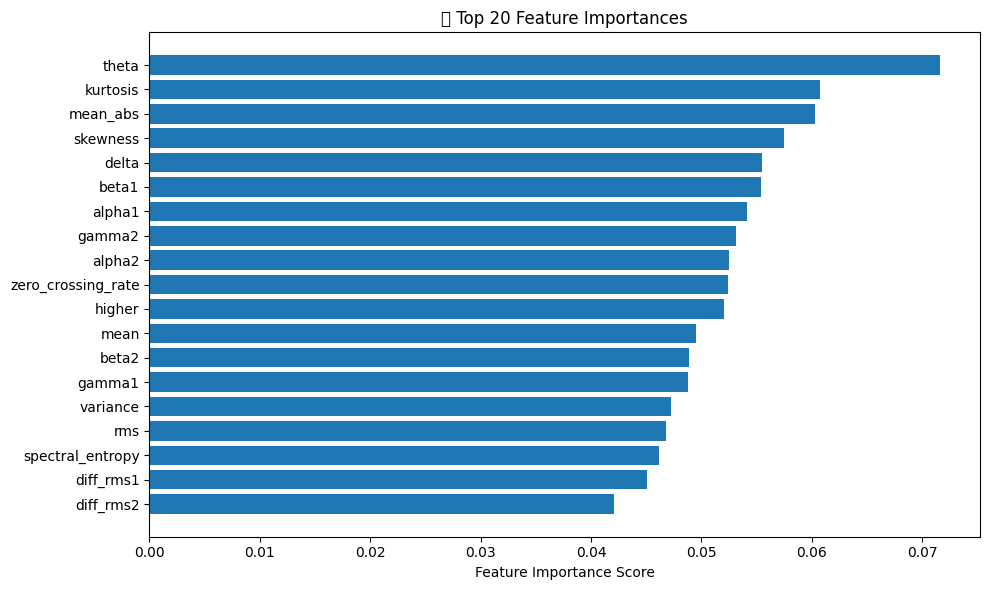

In [21]:
#Rebalanc script
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
import joblib
import matplotlib.pyplot as plt
import numpy as np

# === Paths ===
MERGED_FEATURES_PATH = "C:/Users/Kevin Tran/Documents/Project Data/eeg_features_with_labels2.csv"
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder.pkl"

# === Load Data ===
data = pd.read_csv(MERGED_FEATURES_PATH)

# === Check Class Distribution ===
print("📊 Original Class Distribution:")
print(data["expert_consensus"].value_counts(normalize=True), "\n")

# === Encode Labels ===
label_encoder = LabelEncoder()
data["label_encoded"] = label_encoder.fit_transform(data["expert_consensus"])

# === Prepare Features and Labels ===
X = data.drop(columns=["channel", "eeg_id", "expert_consensus", "label_encoded"])
y = data["label_encoded"]

# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# === Rebalance Training Set ===
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

# === Show New Distribution ===
balanced_labels = label_encoder.inverse_transform(y_train_balanced)
print("✅ Balanced Training Class Distribution:")
print(pd.Series(balanced_labels).value_counts(), "\n")

# === Train Model ===
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# === Evaluate ===
y_pred = rf.predict(X_test)
print("📊 Classification Report (on test set):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# === Save Model & Encoder ===
joblib.dump(rf, MODEL_PATH)
joblib.dump(label_encoder, ENCODER_PATH)

print(f"\n✅ Model saved to: {MODEL_PATH}")
print(f"✅ Label encoder saved to: {ENCODER_PATH}")

# === Feature Importance Plot ===
importances = rf.feature_importances_
feature_names = X.columns  # These are your input features

# Sort by importance
indices = np.argsort(importances)[-20:]  # Top 20 features

# Plot
plt.figure(figsize=(10, 6))
plt.title("🔍 Top 20 Feature Importances")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()



📊 Classification Report (on test set):
              precision    recall  f1-score   support

         GPD       0.63      0.59      0.61       374
        GRDA       0.50      0.44      0.47       378
         LPD       0.63      0.46      0.53       555
        LRDA       0.30      0.11      0.16       208
       Other       0.59      0.81      0.68      1486
     Seizure       0.49      0.32      0.38       602

    accuracy                           0.57      3603
   macro avg       0.52      0.45      0.47      3603
weighted avg       0.56      0.57      0.55      3603


✅ Model saved to: C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model_flat.pkl
✅ Label encoder saved to: C:/Users/Kevin Tran/Documents/Project Data/label_encoder_flat.pkl


C:\Users\Kevin Tran\AppData\Local\Temp\ipykernel_13268\190564418.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  plt.tight_layout()
C:\Users\Kevin Tran\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


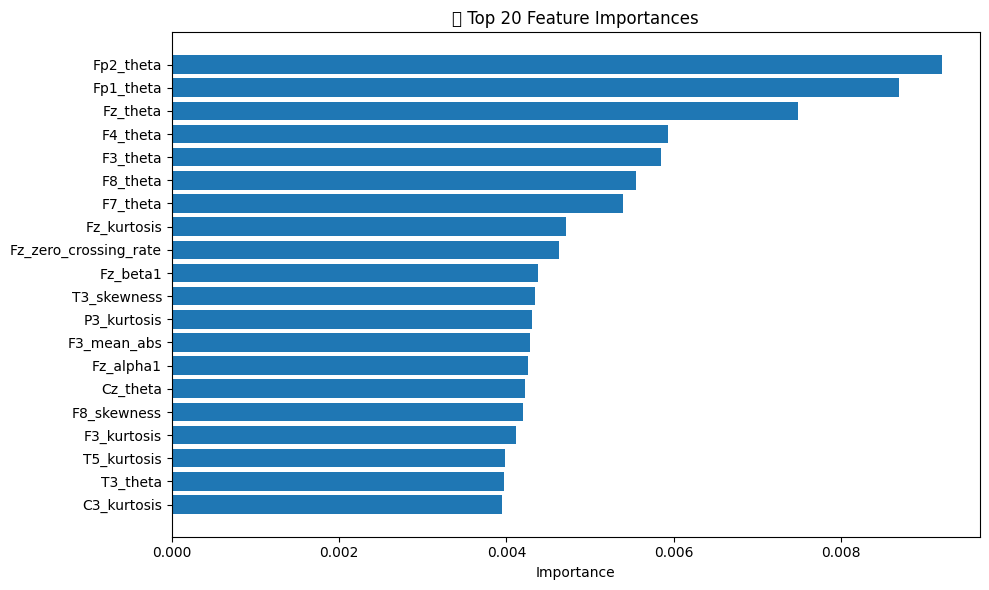

In [ ]:
#flattened training WORKS
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
import joblib
import matplotlib.pyplot as plt
import numpy as np

# === Paths ===
INPUT_FLATTENED_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_features_flattened_labeled.csv"
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model_flat.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder_flat.pkl"

# === Load Flattened Data ===
df = pd.read_csv(INPUT_FLATTENED_CSV)

# === Label Encoding
label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["expert_consensus"])

# === Split features and target
X = df.drop(columns=["eeg_id", "expert_consensus", "label_encoded"])
y = df["label_encoded"]

# === Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# === Rebalance with Oversampling
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

# === Train Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# === Evaluate
y_pred = rf.predict(X_test)
print("\n📊 Classification Report (on test set):")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# === Save Model & Encoder
joblib.dump(rf, MODEL_PATH)
joblib.dump(label_encoder, ENCODER_PATH)
print(f"\n✅ Model saved to: {MODEL_PATH}")
print(f"✅ Label encoder saved to: {ENCODER_PATH}")

# === Plot Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[-20:]  # Top 20

plt.figure(figsize=(10, 6))
plt.title("🔍 Top 20 Feature Importances")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [20]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
import joblib
import mne

# === Paths ===
INPUT_DIR = "C:/Users/Kevin Tran/Documents/Project Data/Input files"
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder.pkl"
OUTPUT_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions.csv"

FS = 200  # Hz

# === EEG Frequency Bands ===
BANDS = {
    "delta": (1, 3), "theta": (4, 7), "alpha1": (8, 9), "alpha2": (10, 12),
    "beta1": (13, 17), "beta2": (18, 30), "gamma1": (31, 40), "gamma2": (41, 50), "higher": (51, 100)
}

# === Preprocessing ===
def apply_notch_filter(signal):
    b, a = iirnotch(w0=60.0, Q=30, fs=FS)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal):
    nyq = 0.5 * FS
    low, high = 0.5 / nyq, 40.0 / nyq
    b, a = butter(5, [low, high], btype='band')
    return filtfilt(b, a, signal)

def normalize_signal(signal):
    return (signal - np.mean(signal)) / np.std(signal)

def apply_ica(df):
    try:
        n_components = min(10, len(df.columns))
        info = mne.create_info(ch_names=list(df.columns), sfreq=FS, ch_types=["eeg"] * len(df.columns))
        raw = mne.io.RawArray(df.values.T, info)
        raw.filter(l_freq=1.0, h_freq=None)
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, max_iter="auto")
        ica.fit(raw)
        raw_clean = ica.apply(raw)
        return pd.DataFrame(raw_clean.get_data().T, columns=df.columns)
    except Exception as e:
        print(f"⚠️ ICA failed: {e}")
        return df

# === Feature Extraction ===
def extract_time_features(signal):
    from scipy.stats import skew, kurtosis
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "zero_crossing_rate": np.sum(np.diff(np.sign(signal)) != 0) / len(signal),
        "mean_abs": np.mean(np.abs(signal)),
        "diff_rms1": np.sqrt(np.mean(np.diff(signal)**2)),
        "diff_rms2": np.sqrt(np.mean(np.diff(signal, n=2)**2)),
    }

def extract_frequency_features(signal):
    L = len(signal)
    Y = np.fft.fft(signal)
    P2 = np.abs(Y / L)
    P1 = P2[:L // 2 + 1]
    P1[1:-1] *= 2
    freqs = FS * np.arange(L // 2 + 1) / L
    band_power = {band: np.sum(P1[(freqs >= low) & (freqs <= high)]) for band, (low, high) in BANDS.items()}
    band_power["spectral_entropy"] = -np.sum(P1 * np.log(P1 + 1e-10))
    return band_power

def extract_features(df):
    features = []
    for ch in df.columns:
        signal = df[ch].values
        tf = extract_time_features(signal)
        ff = extract_frequency_features(signal)
        features.append({**tf, **ff})
    averaged = pd.DataFrame(features).mean().to_frame().T
    return averaged

# === Prediction Loop ===
print(f"📂 Scanning folder: {INPUT_DIR}")
model = joblib.load(MODEL_PATH)
encoder = joblib.load(ENCODER_PATH)

results = []

for fname in os.listdir(INPUT_DIR):
    if not fname.endswith(".parquet"):
        continue

    fpath = os.path.join(INPUT_DIR, fname)
    try:
        df = pd.read_parquet(fpath)

        # Drop EKG if present
        if "EKG" in df.columns:
            df = df.drop(columns=["EKG"])

        if len(df) < 30 * FS:
            print(f"❌ File too short for 10s extraction: {fname}")
            continue

        segment = df.iloc[20 * FS : 30 * FS].copy()

        # Preprocessing
        for ch in segment.columns:
            segment[ch] = normalize_signal(apply_bandpass_filter(apply_notch_filter(segment[ch].values)))

        segment = apply_ica(segment)

        # Extract features
        features = extract_features(segment)

        # Reorder columns to match training
        features = features.reindex(columns=model.feature_names_in_, fill_value=0)

        # Predict
        prediction = model.predict(features)[0]
        label = encoder.inverse_transform([prediction])[0]

        print(f"🧠 {fname} → Predicted: {label}")
        results.append({"eeg_file": fname, "prediction": label})

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        results.append({"eeg_file": fname, "prediction": "Error"})

# === Save Results ===
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ All predictions saved to: {OUTPUT_CSV}")


📂 Scanning folder: C:/Users/Kevin Tran/Documents/Project Data/Input files
Creating RawArray with float64 data, n_channels=19, n_times=2000
    Range : 0 ... 1999 =      0.000 ...     9.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 0.1s.
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
🧠 1202099836.parquet → Predicted: GPD
Creating RawArray with

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 10 components
Fitting ICA took 0.0s.
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
🧠 2277392603.parquet → Predicted: GPD
Creating RawArray with float64 data, n_channels=19, n_times=2000
    Range : 0 ... 1999 =      0.000 ...     9.995 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 661 samples (3.305 s)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by nu

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Fitting ICA took 0.4s.
Applying ICA to Raw instance
    Transforming to ICA space (10 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
🧠 387987538.parquet → Predicted: GRDA

✅ All predictions saved to: C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions.csv


c:\Users\Kevin Tran\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [28]:
#flattened WORKS
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
import joblib
import mne
from tqdm import tqdm

import warnings
import mne

# Suppress MNE and ICA logs
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# === Paths ===
INPUT_DIR = "C:/Users/Kevin Tran/Documents/Project Data/Input files"  # Folder with raw EEG .parquet files
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model_flat.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder_flat.pkl"
OUTPUT_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions_flat.csv"

FS = 200  # Sampling rate

# === EEG Frequency Bands ===
BANDS = {
    "delta": (1, 3), "theta": (4, 7), "alpha1": (8, 9), "alpha2": (10, 12),
    "beta1": (13, 17), "beta2": (18, 30), "gamma1": (31, 40), "gamma2": (41, 50), "higher": (51, 100)
}

# === Signal Preprocessing ===
def apply_notch_filter(signal):
    b, a = iirnotch(w0=60.0, Q=30, fs=FS)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal):
    nyq = 0.5 * FS
    low, high = 0.5 / nyq, 40.0 / nyq
    b, a = butter(5, [low, high], btype='band')
    return filtfilt(b, a, signal)

def normalize_signal(signal):
    return (signal - np.mean(signal)) / np.std(signal)

def apply_ica(df):
    try:
        n_components = min(10, len(df.columns))
        info = mne.create_info(ch_names=list(df.columns), sfreq=FS, ch_types=["eeg"] * len(df.columns))
        raw = mne.io.RawArray(df.values.T, info)
        raw.filter(l_freq=1.0, h_freq=None)
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, max_iter="auto")
        ica.fit(raw)
        raw_clean = ica.apply(raw)
        return pd.DataFrame(raw_clean.get_data().T, columns=df.columns)
    except Exception as e:
        print(f"⚠️ ICA failed: {e}")
        return df

# === Feature Extraction ===
from scipy.stats import skew, kurtosis

def extract_time_features(signal):
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "zero_crossing_rate": np.sum(np.diff(np.sign(signal)) != 0) / len(signal),
        "mean_abs": np.mean(np.abs(signal)),
        "diff_rms1": np.sqrt(np.mean(np.diff(signal)**2)),
        "diff_rms2": np.sqrt(np.mean(np.diff(signal, n=2)**2)),
    }

def extract_frequency_features(signal):
    L = len(signal)
    Y = np.fft.fft(signal)
    P2 = np.abs(Y / L)
    P1 = P2[:L // 2 + 1]
    P1[1:-1] *= 2
    freqs = FS * np.arange(L // 2 + 1) / L
    band_power = {band: np.sum(P1[(freqs >= low) & (freqs <= high)]) for band, (low, high) in BANDS.items()}
    band_power["spectral_entropy"] = -np.sum(P1 * np.log(P1 + 1e-10))
    return band_power

def extract_flattened_features(df):
    all_feats = {}
    for ch in df.columns:
        signal = df[ch].values
        tf = extract_time_features(signal)
        ff = extract_frequency_features(signal)
        for k, v in {**tf, **ff}.items():
            all_feats[f"{ch}_{k}"] = v
    return pd.DataFrame([all_feats])

# === Load Model and Encoder
model = joblib.load(MODEL_PATH)
encoder = joblib.load(ENCODER_PATH)

# === Prediction Loop
results = []
print(f"📂 Scanning: {INPUT_DIR}\n")

for fname in tqdm(os.listdir(INPUT_DIR), desc="Predicting"):
    if not fname.endswith(".parquet"):
        continue

    fpath = os.path.join(INPUT_DIR, fname)
    try:
        df = pd.read_parquet(fpath)

        # Drop EKG if present
        if "EKG" in df.columns:
            df = df.drop(columns=["EKG"])

        if len(df) < 30 * FS:
            print(f"❌ {fname} too short for center 10s.")
            continue

        # Extract 10s center window
        segment = df.iloc[20 * FS : 30 * FS].copy()

        for ch in segment.columns:
            segment[ch] = normalize_signal(apply_bandpass_filter(apply_notch_filter(segment[ch].values)))
        segment = apply_ica(segment)

        features = extract_flattened_features(segment)

        # Align with training features
        missing_cols = [col for col in model.feature_names_in_ if col not in features.columns]
        for col in missing_cols:
            features[col] = 0.0
        features = features[model.feature_names_in_]

        pred = model.predict(features)[0]
        label = encoder.inverse_transform([pred])[0]

        print(f"🧠 {fname} → Predicted: {label}")
        results.append({"eeg_file": fname, "prediction": label})

    except Exception as e:
        print(f"❌ Error in {fname}: {e}")
        results.append({"eeg_file": fname, "prediction": "Error"})

# === Save Results
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ All predictions saved to: {OUTPUT_CSV}")


📂 Scanning: C:/Users/Kevin Tran/Documents/Project Data/Input files



Predicting: 100%|██████████| 1/1 [00:00<?, ?it/s]


✅ All predictions saved to: C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions_flat.csv


In [35]:
#Flattened cleaned up

import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
import joblib
import mne
from tqdm import tqdm
import warnings
from scipy.stats import skew, kurtosis

# === Suppress clutter ===
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# === Paths ===
INPUT_DIR = "C:/Users/Kevin Tran/Documents/Project Data/Input files"
MODEL_PATH = "C:/Users/Kevin Tran/Documents/Project Data/random_forest_eeg_model_flat.pkl"
ENCODER_PATH = "C:/Users/Kevin Tran/Documents/Project Data/label_encoder_flat.pkl"
OUTPUT_CSV = "C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions_flat.csv"
FS = 200  # Hz

# === EEG Frequency Bands ===
BANDS = {
    "delta": (1, 3), "theta": (4, 7), "alpha1": (8, 9), "alpha2": (10, 12),
    "beta1": (13, 17), "beta2": (18, 30), "gamma1": (31, 40),
    "gamma2": (41, 50), "higher": (51, 100)
}

# === Preprocessing ===
def apply_notch_filter(signal):
    b, a = iirnotch(w0=60.0, Q=30, fs=FS)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal):
    nyq = 0.5 * FS
    low, high = 0.5 / nyq, 40.0 / nyq
    b, a = butter(5, [low, high], btype='band')
    return filtfilt(b, a, signal)

def normalize_signal(signal):
    return (signal - np.mean(signal)) / np.std(signal)

def apply_ica(df):
    try:
        n_components = min(10, len(df.columns))
        info = mne.create_info(ch_names=list(df.columns), sfreq=FS, ch_types=["eeg"] * len(df.columns))
        raw = mne.io.RawArray(df.values.T, info)
        raw.filter(l_freq=1.0, h_freq=None)
        ica = mne.preprocessing.ICA(n_components=n_components, random_state=42, max_iter="auto")
        ica.fit(raw)
        raw_clean = ica.apply(raw)
        return pd.DataFrame(raw_clean.get_data().T, columns=df.columns)
    except Exception:
        return df

# === Feature Extraction ===
def extract_time_features(signal):
    return {
        "mean": np.mean(signal),
        "variance": np.var(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "zero_crossing_rate": np.sum(np.diff(np.sign(signal)) != 0) / len(signal),
        "mean_abs": np.mean(np.abs(signal)),
        "diff_rms1": np.sqrt(np.mean(np.diff(signal)**2)),
        "diff_rms2": np.sqrt(np.mean(np.diff(signal, n=2)**2)),
    }

def extract_frequency_features(signal):
    L = len(signal)
    Y = np.fft.fft(signal)
    P2 = np.abs(Y / L)
    P1 = P2[:L // 2 + 1]
    P1[1:-1] *= 2
    freqs = FS * np.arange(L // 2 + 1) / L
    band_power = {band: np.sum(P1[(freqs >= low) & (freqs <= high)]) for band, (low, high) in BANDS.items()}
    band_power["spectral_entropy"] = -np.sum(P1 * np.log(P1 + 1e-10))
    return band_power

def extract_flattened_features(df):
    all_feats = {}
    for ch in df.columns:
        signal = df[ch].values
        tf = extract_time_features(signal)
        ff = extract_frequency_features(signal)
        for k, v in {**tf, **ff}.items():
            all_feats[f"{ch}_{k}"] = v
    return pd.DataFrame([all_feats])

# === Load Model & Encoder
model = joblib.load(MODEL_PATH)
encoder = joblib.load(ENCODER_PATH)

# === Collect files
all_files = sorted([
    f for f in os.listdir(INPUT_DIR)
    if f.endswith(".parquet") and not f.startswith("~") and not f.startswith(".")
])
print(f"📂 Found {len(all_files)} valid EEG files to process.\n")

# === Prediction Loop
results = []
for fname in tqdm(all_files, desc="Predicting"):
    fpath = os.path.join(INPUT_DIR, fname)
    try:
        df = pd.read_parquet(fpath)

        # Drop EKG if present
        if "EKG" in df.columns:
            df = df.drop(columns=["EKG"])

        if len(df) < 30 * FS:
            print(f"⚠️ Skipping {fname}: too short")
            continue

        # Extract center 10s segment
        segment = df.iloc[20 * FS : 30 * FS].copy()

        for ch in segment.columns:
            segment[ch] = normalize_signal(apply_bandpass_filter(apply_notch_filter(segment[ch].values)))

        segment = apply_ica(segment)
        features = extract_flattened_features(segment)

        # Ensure matching feature names
        for col in model.feature_names_in_:
            if col not in features.columns:
                features[col] = 0.0
        features = features[model.feature_names_in_]

        # Predict
        pred = model.predict(features)[0]
        label = encoder.inverse_transform([pred])[0]

        print(f"🧠 {fname} → Predicted: {label}")
        results.append({"eeg_file": fname, "prediction": label})

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        results.append({"eeg_file": fname, "prediction": "Error"})

# === Save Predictions
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ All predictions saved to: {OUTPUT_CSV}")


📂 Found 6 valid EEG files to process.



Predicting:  33%|███▎      | 2/6 [00:00<00:00, 11.86it/s]

🧠 193769323.parquet → Predicted: GRDA
🧠 2621657604.parquet → Predicted: Seizure
🧠 3165229298.parquet → Predicted: GPD


Predicting:  67%|██████▋   | 4/6 [00:00<00:00, 11.58it/s]

🧠 3359683976.parquet → Predicted: LRDA


Predicting: 100%|██████████| 6/6 [00:00<00:00,  6.71it/s]

🧠 4132664035.parquet → Predicted: Other
🧠 741501690.parquet → Predicted: LPD

✅ All predictions saved to: C:/Users/Kevin Tran/Documents/Project Data/eeg_predictions_flat.csv
